In [1]:
# imports
import pandas as pd
import os
import numpy as np 
import json
import skimage as ski
import matplotlib.pyplot as plt
from skimage.measure import find_contours
from matplotlib import colors

C:\Users\marie\AppData\Local\Temp\ipykernel_34968\3977343045.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [25]:
# data sources
label_path = r"C:\Users\marie\rep_codes\udder_project\udder_processing\validate_watershed\pred_labels"
image_path = r"C:\Users\marie\rep_codes\udder_project\udder_video\depth_images"
ws_path = r"C:\Users\marie\rep_codes\udder_project\udder_processing\validate_watershed\watershed_data\array"
segment_path = os.path.join(label_path, "segments")
keypoint_path = os.path.join(label_path, "keypoints")

In [26]:
image_name = '978_20231117_170827_frame_148'
image_name2 = "978_20231117_170827_frame_138"
kp_filepath = os.path.join(keypoint_path, f"{image_name}.txt")
sg_filepath = os.path.join(segment_path, f"{image_name}.txt")
ws_filepath = os.path.join(ws_path, f"{image_name}.npy")

In [74]:
img = ski.io.imread(os.path.join(image_path, image_name.split("_")[0], f"{image_name}.tif"))
img_size = img.shape
with open(sg_filepath, "r") as f:
    udder_segment = np.array([float(point) for point in f.read().split(" ")][1:])
    udder_segment = udder_segment.reshape((int(len(udder_segment)//2),2))
with open(kp_filepath, "r") as f:
    data =  [float(point) for point in f.read().split(" ")]
    points = np.array(data[5:])
points = points.reshape((4,3))
points[:, 0] = points[:, 0] * img_size[1]
points[:, 1] = points[:, 1] * img_size[0]
udder_coords = np.array([[coord[0] * img_size[1], coord[1]* img_size[0]] for coord in udder_segment])
polygon2 = [[coord[1]* img_size[0], coord[0] * img_size[1]] for coord in udder_segment]
udder_mask = ski.draw.polygon2mask(img_size, polygon2)
masked_image = img.copy()
masked_image[udder_mask == 0] = 0
contour = find_contours(udder_mask)[0]
polygon = np.array([[coord[1], coord[0]] for coord in contour])

ws_mask = np.load(ws_filepath)
ws_mask2 = ws_mask[:, :, 0]*2+ ws_mask[:, :, 1]*4 + ws_mask[:, :, 2]*6
seg_contours = find_contours(ws_mask2)

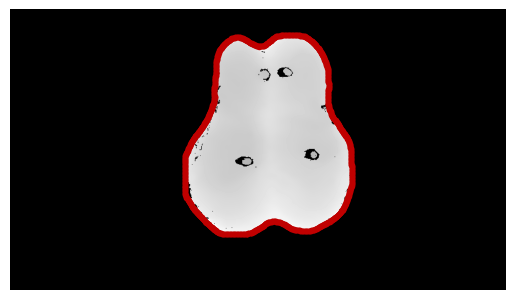

In [88]:
cmap = colors.ListedColormap(["black", "white"])
fig, axs = plt.subplots()
axs.imshow(masked_image, cmap = "gray")
axs.imshow(udder_mask, alpha = 0.0, cmap = cmap)
axs.plot(polygon[:, 0], polygon[:, 1], ".", color = "#C00000")
axs.axis('off')
fig.savefig("segment.png", bbox_inches='tight', pad_inches=0)

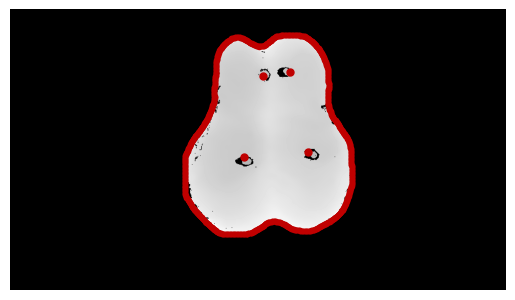

In [87]:
fig, axs = plt.subplots()
axs.imshow(masked_image, cmap = "gray")
axs.imshow(udder_mask, alpha = 0, cmap = cmap)
axs.plot(polygon[:, 0], polygon[:, 1], ".", color = "#C00000")
axs.plot(points[2:, 0], points[2:, 1]-10, ".", color = "#C00000",  markersize= 10)
axs.plot(points[:2, 0], points[:2, 1], ".", color = "#C00000",  markersize= 10)
axs.axis('off')
fig.savefig("kpoints.png", bbox_inches='tight', pad_inches=0)

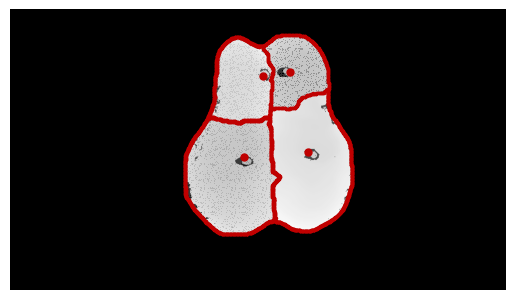

In [90]:

cmap = colors.ListedColormap(["black", "darkgray",  "dimgray",  "silver", "white"])
fig, axs = plt.subplots()
axs.imshow(masked_image, cmap = "gray")
axs.imshow(udder_mask, alpha = 0, cmap = cmap)
axs.plot(polygon[:, 0], polygon[:, 1], ".", color = "#C00000", markersize= 3)
axs.plot(points[2:, 0], points[2:, 1]-10, ".", color = "#C00000",  markersize= 10)
axs.plot(points[:2, 0], points[:2, 1], ".", color = "#C00000",  markersize= 10)
axs.imshow(np.floor(ws_mask2), cmap = cmap, alpha = 0.3)
for contour in seg_contours:
    axs.plot(contour[:, 1], contour[:, 0], ".", color = "#C00000", markersize= 3)
axs.axis('off')
fig.savefig("ws.png", bbox_inches='tight', pad_inches=0)

In [77]:
len(seg_contours[0])

539

In [49]:
ws_mask

255.0